# **ML Terapan - Submission Akhir Membuat Model Sistem Rekomendasi**
- **Nama:** Lutfi Aundrie Hermawan
- **Email:** lutfiaunher@gmail.com
- **ID Dicoding:** A126YBF254


## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error

## Data Preparation

Download Dataset Amazon Prime Movies and TV Shows melalui Google Drive

[Google Drive](https://drive.google.com/drive/folders/1uqDIWoNldmUZi_kiGxlpiLSsVmsmVPHz?usp=sharing)

[Kaggle](https://www.kaggle.com/datasets/dgoenrique/amazon-prime-movies-and-tv-shows/data)

## **Mount to Drive**

Menghubungkan penyimpanan Google Drive ke Colab dan mengakses file yang disimpan di Google Drive langsung dari notebook.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Read Dataset**

Memuat data dari csv ke dataframe

In [3]:
df= pd.read_csv('/content/drive/MyDrive/Submission/Submission_One_ML_Terapan/Amazon_Prime_Video/titles.csv')
df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm87233,It's a Wonderful Life,MOVIE,A holiday favourite for generations... George...,1946,PG,130,"['drama', 'family', 'fantasy', 'romance', 'com...",['US'],NaN,tt0038650,8.6,467766.0,27.611,8.261
1,tm143047,Duck Soup,MOVIE,Rufus T. Firefly is named president/dictator o...,1933,NaN,69,"['comedy', 'war']",['US'],NaN,tt0023969,7.8,60933.0,9.013,7.357
2,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['drama', 'romance', 'comedy']",['US'],NaN,tt0032599,7.8,60244.0,14.759,7.433
3,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family']",['US'],26.0,tt0850645,8.5,1149.0,15.424,7.600
4,tm5012,Red River,MOVIE,Headstrong Thomas Dunson starts a thriving Tex...,1948,NaN,133,"['western', 'drama', 'romance', 'action']",['US'],NaN,tt0040724,7.8,32210.0,12.400,7.400


In [4]:
df_credits= pd.read_csv('/content/drive/MyDrive/Submission/Submission_One_ML_Terapan/Amazon_Prime_Video/credits.csv')
df_credits.head()

,person_id,id,name,character,role
0,25020,tm87233,James Stewart,George Bailey,ACTOR
1,26190,tm87233,Donna Reed,Mary Hatch,ACTOR
2,25653,tm87233,Lionel Barrymore,Mr. Potter,ACTOR
3,13301,tm87233,Thomas Mitchell,Uncle Billy,ACTOR
4,34171,tm87233,Henry Travers,Clarence,ACTOR


## Data Understanding

###**1. Dataset Information**

Melihat informasi dari dataframe. Dari informasi tersebut bahwa dataset memiliki jumlah data sebanyak 12 kolom dan 9668 baris

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10873 entries, 0 to 10872
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10873 non-null  object 
 1   title                 10873 non-null  object 
 2   type                  10873 non-null  object 
 3   description           10729 non-null  object 
 4   release_year          10873 non-null  int64  
 5   age_certification     3688 non-null   object 
 6   runtime               10873 non-null  int64  
 7   genres                10873 non-null  object 
 8   production_countries  10873 non-null  object 
 9   seasons               1551 non-null   float64
 10  imdb_id               10172 non-null  object 
 11  imdb_score            9765 non-null   float64
 12  imdb_votes            9753 non-null   float64
 13  tmdb_popularity       10302 non-null  float64
 14  tmdb_score            8747 non-null   float64
dtypes: float64(5), int6

Melihat informasi dari dataframe. Dari informasi tersebut bahwa dataset memiliki jumlah data sebanyak 5 kolom dan 140553 baris

In [6]:
df_credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140553 entries, 0 to 140552
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  140553 non-null  int64 
 1   id         140553 non-null  object
 2   name       140553 non-null  object
 3   character  122705 non-null  object
 4   role       140553 non-null  object
dtypes: int64(1), object(4)
memory usage: 5.4+ MB


###**2. Check Missing Values**

Memeriksa nilai yang hilang (missing values) dalam dataset. Dari dataset ini bahwa missing values berjumlah 5 dimana presentasi missing values besar

In [7]:
print("\nMissing values dalam dataset:")
print(df.isnull().sum())


Missing values dalam dataset:
id                         0
title                      0
type                       0
description              144
release_year               0
age_certification       7185
runtime                    0
genres                     0
production_countries       0
seasons                 9322
imdb_id                  701
imdb_score              1108
imdb_votes              1120
tmdb_popularity          571
tmdb_score              2126
dtype: int64


In [8]:
missing_num = df[df.columns].isna().sum().sort_values(ascending=False)
missing_perc = (df[df.columns].isna().sum()/len(df)*100).sort_values(ascending=False)
missing = pd.concat([missing_num,missing_perc],keys=['Total','Percentage'],axis=1)
missing_train = missing[missing['Percentage']>0]
missing_train

,Total,Percentage
seasons,9322,85.735308
age_certification,7185,66.081118
tmdb_score,2126,19.553021
imdb_votes,1120,10.300745
imdb_score,1108,10.190380
imdb_id,701,6.447163
tmdb_popularity,571,5.251541
description,144,1.324381


Berdasarkan data pada dataset, terdapat nilai hilang (missing value) yang cukup tinggi pada kolom seasons dan age_certification, yaitu dengan persentase di atas 60%. Namun untuk "seasons" tidak perlu didrop dikarenakan pada "typre : Movie" tidak ada season dan hanya perlu diisi nilai 0. Sedangkan "age_certification" untuk nilai kosong diisi "UnRated"

## **Exploratory Data Analysis**

###**1. Tahun Rilis Terbanyak**

Visualisasi distribusi tahun rilis untuk Movie dan TV Show menunjukkan bahwa penambahan konten baru mengalami peningkatan signifikan pada rentang tahun 2015 hingga 2020. Pada periode ini, jumlah konten yang dirilis merupakan yang terbanyak dibandingkan tahun-tahun sebelumnya.

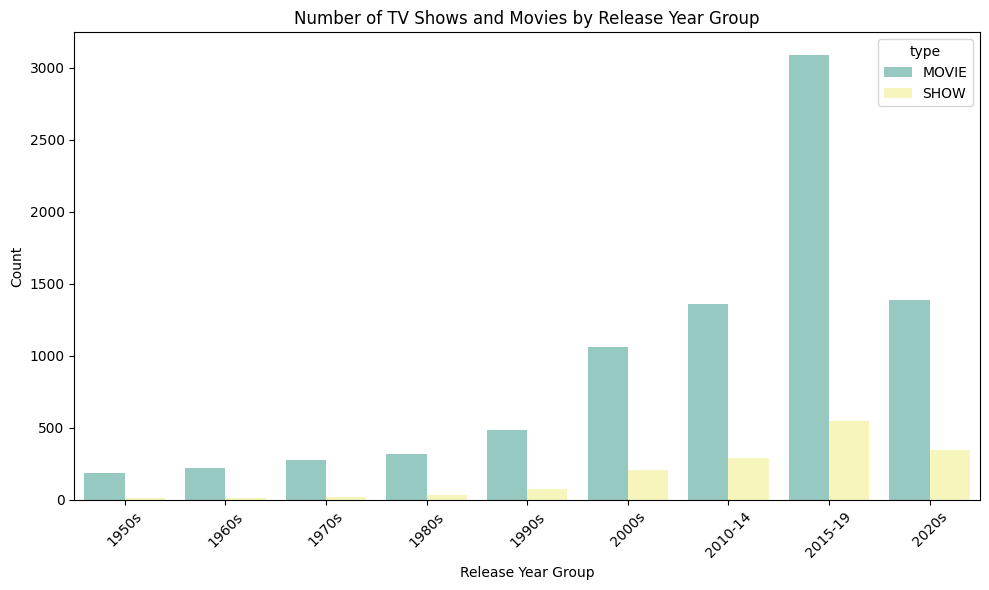

In [9]:
# Pastikan kolom 'release_year' dalam format numerik
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

# Buat grup tahun (opsional, untuk mengurangi noise jika tahun sangat banyak)
bins = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2015, 2020, 2025]
labels = ['1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010-14', '2015-19', '2020s']
df['year_group'] = pd.cut(df['release_year'], bins=bins, labels=labels)

# Plot menggunakan seaborn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='year_group', hue='type', palette='Set3')
plt.title('Number of TV Shows and Movies by Release Year Group')
plt.xlabel('Release Year Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###**2. Distribusi Age Certification**

Distribusi konten berdasarkan Age Certification menunjukkan bahwa Amazon Prime memiliki banyak konten yang ditujukan untuk audiens remaja. Hal ini terlihat dari dominasi kategori Age Certification seperti "R" dan "PG-13", yang merupakan dua kategori dengan jumlah konten terbanyak di platform tersebut.

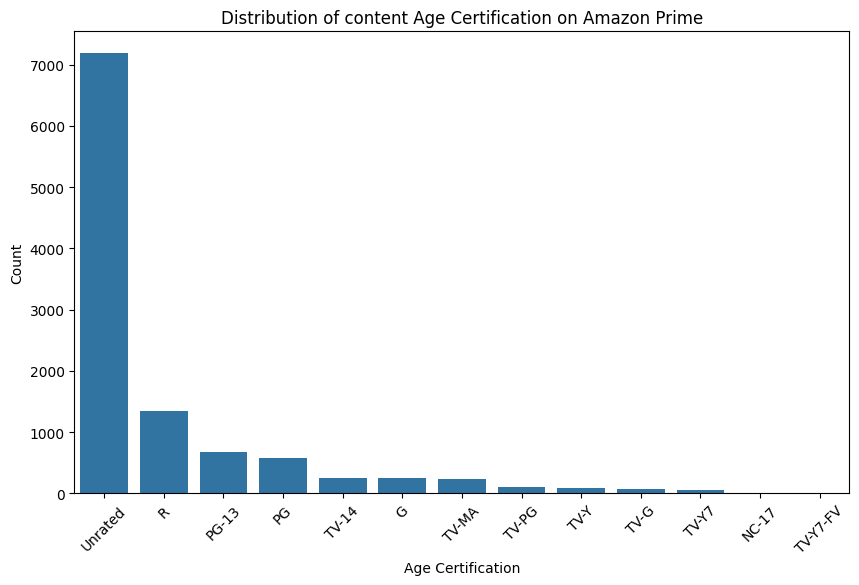

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(x='age_certification', order = df['age_certification'].value_counts().index, data = df)
plt.title('Distribution of content Age Certification on Amazon Prime')
plt.xlabel('Age Certification')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

### **3. Top Genre Amazon Prime**

Menvisualisasi genre top 5 di Amazon Prime. Visualisasi menunjukkan bahwa genre yang paling banyak ditampilkan dalam dataset adalah Drama, Comedy, Thriller, Action, dan Romance. Kelima genre ini merupakan genre terpopuler dengan jumlah konten terbanyak.

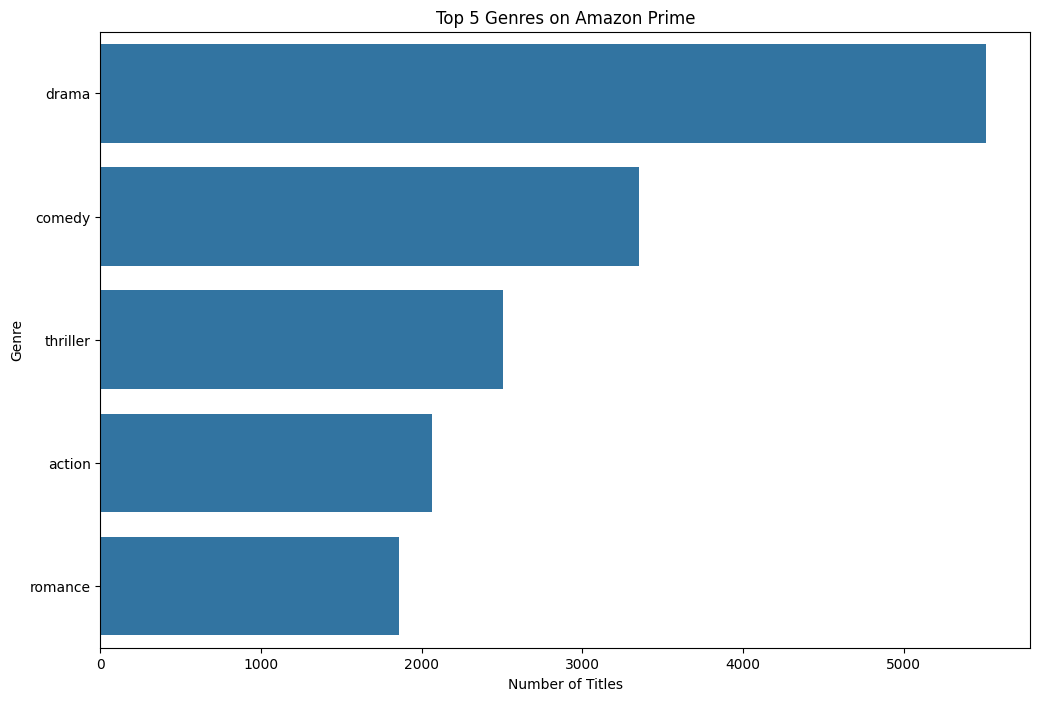

In [11]:
import ast

# Ubah string list menjadi list Python menggunakan ast.literal_eval
df['genres'] = df['genres'].apply(ast.literal_eval)

# Hitung frekuensi genre
genre_counts = df.explode('genres')['genres'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values[:5], y=genre_counts.index[:5])
plt.title('Top 5 Genres on Amazon Prime')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.show()

###**4. Distribusi Durasi Movie**

Visualisasi menunjukkan distribusi durasi film di Amazon Prime, dengan mayoritas Movie memiliki durasi antara 80 hingga 120 menit. Hal ini mencerminkan preferensi umum terhadap film berdurasi standar.

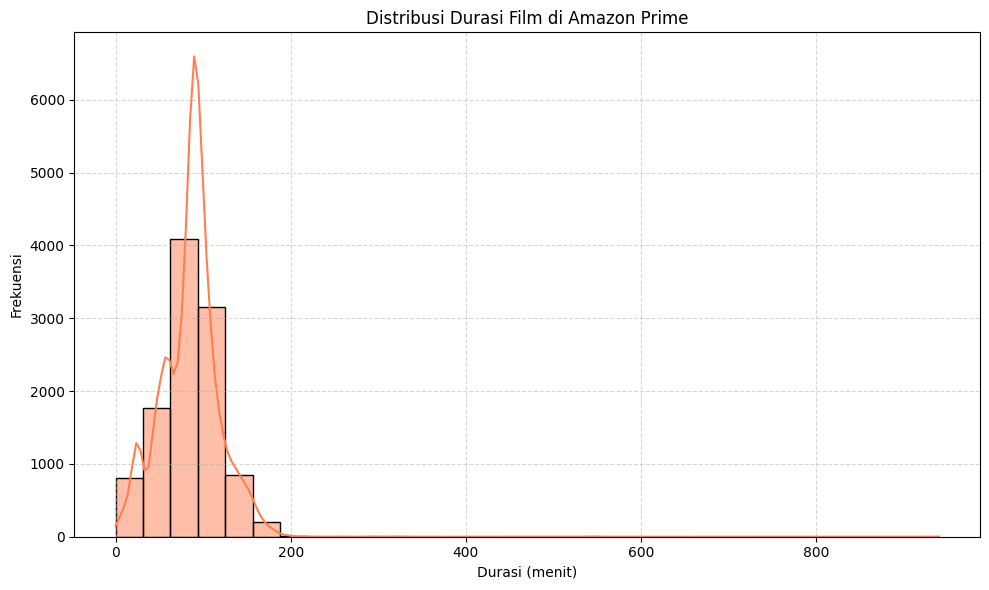

In [12]:
# Plot distribusi
plt.figure(figsize=(10, 6))
sns.histplot(df['runtime'].dropna(), bins=30, kde=True, color='coral')
plt.title('Distribusi Durasi Film di Amazon Prime')
plt.xlabel('Durasi (menit)')
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###**5. Distribusi Durasi TV Series**

Visualisasi menunjukkan distribusi jumlah season pada TV Show di Amazon Prime. Mayoritas serial memiliki hanya 1 season, menunjukkan dominasi format mini series atau limited series di platform ini.

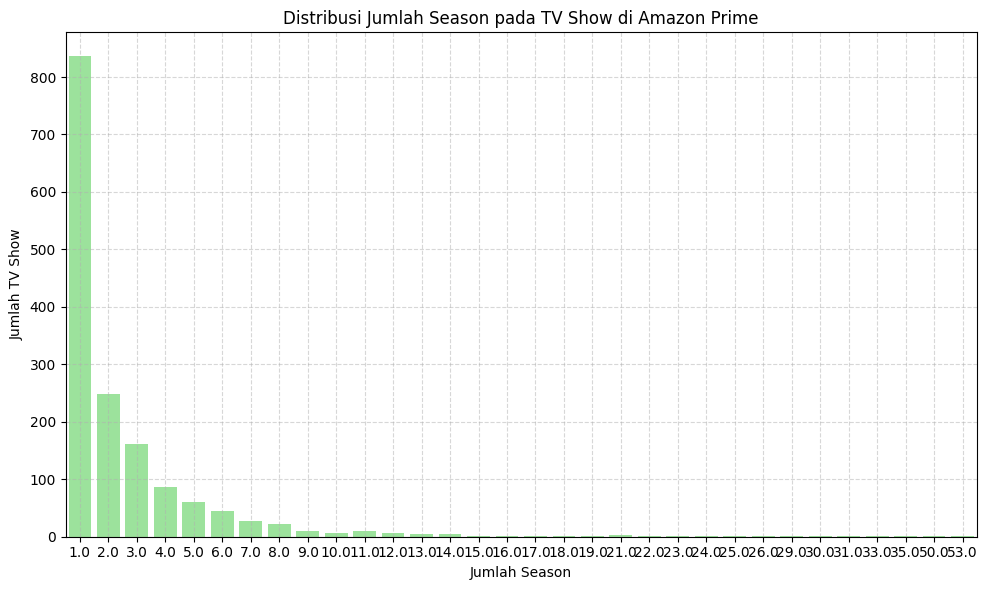

In [13]:
# Visualisasi distribusi jumlah season
plt.figure(figsize=(10, 6))
sns.countplot(x='seasons', data=df, color='lightgreen')
plt.title('Distribusi Jumlah Season pada TV Show di Amazon Prime')
plt.xlabel('Jumlah Season')
plt.ylabel('Jumlah TV Show')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

###**6. Distribusi Rating IMBD Score**

Visualisasi menunjukkan bahwa skor IMBD rata rata sekitar 6 - 6,5 dari 10 untuk keseluruhan movie maupun TV series

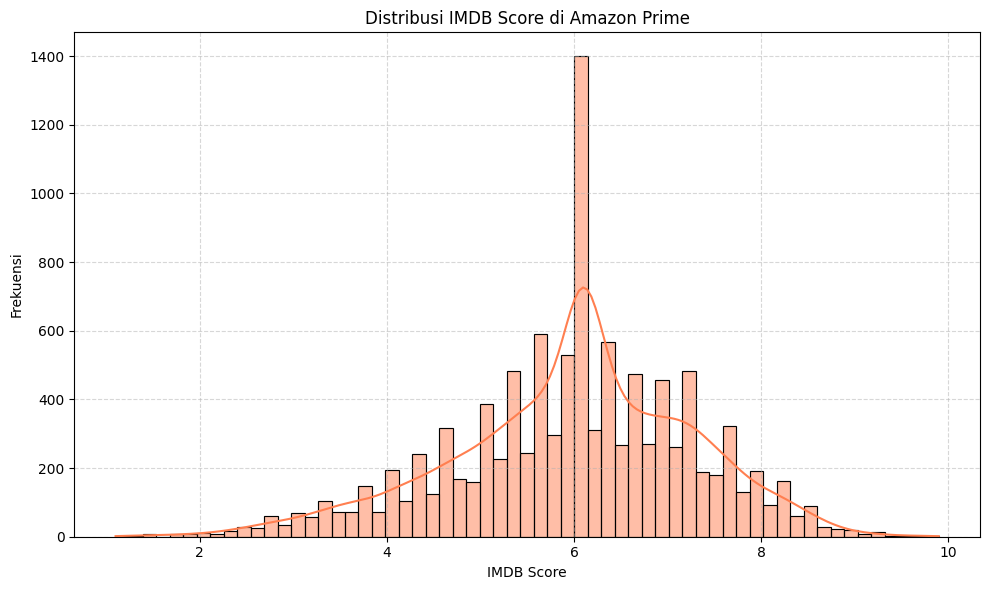

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df['imdb_score'].dropna(), kde=True, color='coral')
plt.title('Distribusi IMDB Score di Amazon Prime') # Corrected title
plt.xlabel('IMDB Score') # Corrected xlabel
plt.ylabel('Frekuensi')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Data Preparation**

###**Handling Missing Values**

Nilai yang hilang pada kolom Age Certification akan diimputant dengan data "Unrated"

In [14]:
df['age_certification'] = df['age_certification'].fillna('Unrated')

Nilai yang hilang pada kolom Seasons akan diisi dengan data "0" dikarenakan tidak ada season

In [15]:
df['seasons'] = df['seasons'].fillna(0)

Untuk nilai yang hilang pada akan diimputant

In [16]:
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].median())
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].median())
df['tmdb_popularity'] = df['tmdb_popularity'].fillna(df['tmdb_popularity'].median())
df['imdb_votes'] = df['imdb_votes'].fillna(0)
df['description'] = df['description'].fillna('No description available.')

df['has_imdb'] = df['imdb_id'].notna()

Cek kembali Missing Value setelah dilakukan Handling

In [17]:
# Cek missing values
missing_values = df.isnull().sum()
print(missing_values)

id                        0
title                     0
type                      0
description               0
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                 701
imdb_score                0
imdb_votes                0
tmdb_popularity           0
tmdb_score                0
year_group              933
has_imdb                  0
dtype: int64


Hapus apabila tidak diperlukan

### **Handling Data**

Mengekstrak genre pertama dan negara produksi pertama dari kolom yang berisi string list

In [18]:
# Pastikan kolom 'genres' dan 'production_countries' adalah string
df['genres'] = df['genres'].astype(str)
df['production_countries'] = df['production_countries'].astype(str)

# Mengekstrak genre pertama dan negara produksi pertama dari kolom yang berisi string list
df['genres'] = df['genres'].str.replace('[', '', regex=False)\
                                   .str.replace(']', '', regex=False)\
                                   .str.replace("'", '', regex=False)
df['genre'] = df['genres'].str.split(',').str[0].str.strip()

In [19]:
# Assuming you meant to clean 'production_countries' column in the 'df' DataFrame
df['production_countries'] = df['production_countries'].str.replace('[', '', regex=False)\
                                                               .str.replace(']', '', regex=False)\
                                                               .str.replace("'", '', regex=False)
df['production_country'] = df['production_countries'].str.split(',').str[0].str.strip()

Pisahkan kolom Role "DIRECTOR" dan "ACTORS"

In [20]:
# Pisahkan DIRECTOR
directors = df_credits[df_credits['role'] == 'DIRECTOR'].groupby('id')['name'].first().reset_index()
directors.columns = ['id', 'director']
print(directors.head())

          id            director
0   tm100001  Robert N. Bradbury
1  tm1000022          Liang Ding
2  tm1000169         Diane Cossa
3  tm1000203  Michael P. Blevins
4  tm1000290      Michael Feifer


In [21]:
actors = df_credits[df_credits['role'] == 'ACTOR'].groupby('id')['name'].apply(lambda x: ', '.join(x)).reset_index()
actors.columns = ['id', 'cast']
print(actors.head())

          id                                               cast
0   tm100001  John Wayne, Barbara Sheldon, Lloyd Whitlock, G...
1  tm1000022        Xiao Tan, Wei Zhang, Bingjun Zhang, Pei Liu
2  tm1000169  John Rhys-Davies, Shane Nepveu, Briana Marin, ...
3  tm1000203  Ford Austin, Tom Fitzpatrick, Rachel Alig, Ric...
4  tm1000290  Cerina Vincent, Emily Skinner, Brian Krause, A...


Gabungkan kolom df_credits ke df

In [22]:
df = df.merge(directors, on='id', how='left')
df = df.merge(actors, on='id', how='left')

In [23]:
df_clean=df.copy()

### 4. Feature Engineering

Menggabungkan berbagai kolom teks (seperti title, director, cast, listed_in, dan description) menjadi satu kolom baru content. Hal ini dilakukan untuk memberikan representasi teks yang lebih komprehensif tentang film atau acara yang ada.

In [24]:
df_CBF=df_clean.copy()

In [25]:
# Ambil kolom yang relevan
df_CBF['combined_features'] = df_CBF[['title', 'description', 'cast', 'genres', 'director']] \
                    .fillna('').agg(' '.join, axis=1)

In [26]:
df_CBF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10873 entries, 0 to 10872
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id                    10873 non-null  object  
 1   title                 10873 non-null  object  
 2   type                  10873 non-null  object  
 3   description           10873 non-null  object  
 4   release_year          10873 non-null  int64   
 5   age_certification     10873 non-null  object  
 6   runtime               10873 non-null  int64   
 7   genres                10873 non-null  object  
 8   production_countries  10873 non-null  object  
 9   seasons               10873 non-null  float64 
 10  imdb_id               10172 non-null  object  
 11  imdb_score            10873 non-null  float64 
 12  imdb_votes            10873 non-null  float64 
 13  tmdb_popularity       10873 non-null  float64 
 14  tmdb_score            10873 non-null  float64 
 15  ye

### 5. Transformasi Teks ke Vektor Numerik menggunakan TF-IDF Vectorizer

In [27]:
# Ubah ke dalam bentuk vektor TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_CBF['combined_features'])

# Cek hasil vektorisasi
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (10873, 82461)


In [28]:
# Konversi TF-IDF matrix ke bentuk dense dan buat DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.todense(),
    columns=tfidf.get_feature_names_out(),
    index=df_CBF['title']
)

# Tampilkan 5 baris pertama
print(tfidf_df.head())

                        00       000  000th  007   01   03  032  0d1285eb  \
title                                                                       
It's a Wonderful Life  0.0  0.050947    0.0  0.0  0.0  0.0  0.0       0.0   
Duck Soup              0.0  0.000000    0.0  0.0  0.0  0.0  0.0       0.0   
His Girl Friday        0.0  0.000000    0.0  0.0  0.0  0.0  0.0       0.0   
The Three Stooges      0.0  0.000000    0.0  0.0  0.0  0.0  0.0       0.0   
Red River              0.0  0.000000    0.0  0.0  0.0  0.0  0.0       0.0   

                        10  100  ...  곽형철  김범태  김정교   덩커   부릉  브루미즈  신유선   와콘  \
title                            ...                                            
It's a Wonderful Life  0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
Duck Soup              0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
His Girl Friday        0.0  0.0  ...  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0   
The Three Stooges      0.0  0.0  ...  0.0  0.0  0.0  0.

##**Modelling**

###**1. Model Development Content Based Filtering**

Digunakan untuk merekomendasikan film atau TV show berdasarkan kemiripan konten seperti genre, deskripsi, sutradara, dll.

In [29]:
# Hitung kemiripan antar konten
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Buat mapping antara judul dan index DataFrame
indices = pd.Series(df.index, index=df_CBF['title'].str.lower()).drop_duplicates()

Matriks Kemiripan Antar Judul

In [30]:
cosine_sim_df = pd.DataFrame(cosine_sim,
                             index=df_CBF['title'],
                             columns=df_CBF['title'])
print(f"Cosine Similarity Matrix Shape: {cosine_sim_df.shape}")

Cosine Similarity Matrix Shape: (10873, 10873)


In [31]:
print("Sample Cosine Similarity Matrix:")
print(cosine_sim_df.sample(5, axis=1, random_state=42).sample(10, axis=0, random_state=42)
)

Sample Cosine Similarity Matrix:
title                                Open Graves  Digging to Death  \
title                                                                
Open Graves                             1.000000          0.005245   
Digging to Death                        0.005245          1.000000   
The Grand Tour                          0.007073          0.018771   
Maze                                    0.007780          0.003384   
Sita Ramam                              0.000000          0.006124   
All Through the House                   0.027390          0.022807   
Avenge the Crows                        0.001659          0.002299   
Befikre                                 0.000000          0.010009   
The Adventures of Ozzie and Harriet     0.000000          0.011166   
Putham Pudhu Kaalai                     0.000000          0.000000   

title                                The Grand Tour      Maze  Sita Ramam  
title                                             

#### **Sistem Rekomendasi**

In [32]:
# Hitung cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Membuat fungsi rekomendasi berbasis konten
def get_recommendations(title, df_CBF, cosine_sim_matrix, top_n=10):
    title = title.strip()

    # Cek apakah judul ada di DataFrame
    if title not in df_CBF['title'].values:
        return f"[ERROR] Judul '{title}' tidak ditemukan dalam dataset."

    # Temukan indeks berdasarkan judul
    idx = df_CBF[df_CBF['title'] == title].index[0]

    # Ambil skor similarity untuk semua item
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))

    # Urutkan berdasarkan similarity tertinggi
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Ambil top_n hasil teratas, selain dirinya sendiri (index 0)
    top_indices = [i[0] for i in sim_scores[1:top_n+1]]

    # Ambil judul film/TV show sebagai hasil
    recommended = df_CBF[['title', 'type', 'genres']].iloc[top_indices]
    recommended['similarity_score'] = [sim_scores[i+1][1] for i in range(top_n)]

    return recommended.reset_index(drop=True)

# Contoh penggunaan
recommendations = get_recommendations("Digging to Death", df_CBF, cosine_sim)
print(recommendations)

                   title   type                           genres  \
0         Bullitt County  MOVIE          action, drama, thriller   
1      At Granny's House  MOVIE                         thriller   
2                  Bleed  MOVIE                 horror, thriller   
3                  Karma  MOVIE  drama, thriller, comedy, action   
4            The Handler  MOVIE   action, drama, thriller, crime   
5          Sniper Corpse  MOVIE                           horror   
6                The Bat  MOVIE                 horror, thriller   
7  House on Haunted Hill  MOVIE                    horror, crime   
8     Devil in the Flesh  MOVIE                 horror, thriller   
9            Three Pines   SHOW                     crime, drama   

   similarity_score  
0          0.115214  
1          0.112151  
2          0.108470  
3          0.098885  
4          0.097815  
5          0.095206  
6          0.094364  
7          0.089328  
8          0.084746  
9          0.084620  


####**Evaluasi Model Development Content Based Filtering**

In [33]:
relevant_movies = [
    'Putham Pudhu Kaalai ',
    'Digging to Death',
    'All Through the House',
    'Sita Ramam'
]

In [34]:
def precision_at_k(recommended, relevant, k):
    if not recommended or k == 0:
        return 0.0
    recommended_at_k = set(recommended[:k])
    relevant_set = set(relevant)
    precision = len(recommended_at_k & relevant_set) / k
    return round(precision, 4)

def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    recommended_at_k = set(recommended[:k])
    relevant_set = set(relevant)
    recall = len(recommended_at_k & relevant_set) / len(relevant_set)
    return round(recall, 4)

def f1_score_at_k(recommended, relevant, k):
    precision = precision_at_k(recommended, relevant, k)
    recall = recall_at_k(recommended, relevant, k)
    if precision + recall == 0:
        return 0.0
    f1 = 2 * (precision * recall) / (precision + recall)
    return round(f1, 4)

In [35]:
def evaluate_recommendation_system(query_title, ground_truth, k=10):
    try:
        recommendations = get_recommendations(query_title, df_clean, cosine_sim)

        # Extract list of recommended titles
        recommended_titles = recommendations['title'].tolist()

        precision = precision_at_k(recommended_titles, ground_truth, k)
        recall = recall_at_k(recommended_titles, ground_truth, k)
        f1 = f1_score_at_k(recommended_titles, ground_truth, k)

        print(f"\nEvaluation for: '{query_title}'")
        print(f"Top-{k} Recommendations: {recommended_titles[:k]}")
        print(f"Ground Truth: {ground_truth}")
        print(f"\nPrecision@{k}: {precision}")
        print(f"Recall@{k}:    {recall}")
        print(f"F1-Score@{k}:  {f1}")

        return {
            "precision": precision,
            "recall": recall,
            "f1_score": f1
        }

    except Exception as e:
        print(f"[ERROR] Gagal mengevaluasi: {e}")
        return None


evaluate_recommendation_system("Bleed", relevant_movies, k=10)


Evaluation for: 'Bleed'
Top-10 Recommendations: ['DIVE!!', 'Digging to Death', 'Girl, Chill', 'Twinsanity', 'Cave Club', 'Chicago Massacre: Richard Speck', 'Seven Alone', 'Hellblock 13', 'Devil in the Flesh', 'Erik Terrell: Live at the Helium Comedy Club']
Ground Truth: ['Putham Pudhu Kaalai ', 'Digging to Death', 'All Through the House', 'Sita Ramam']

Precision@10: 0.1
Recall@10:    0.25
F1-Score@10:  0.1429


{'precision': 0.1, 'recall': 0.25, 'f1_score': 0.1429}

###**2. Model Development Collaborative Filtering**

In [36]:
df_CF=df_clean.copy()

In [37]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_CF['userId'] = np.random.randint(1, 1001, df_CF.shape[0])
df_CF['movseri_id'] = df_CF['id'].astype('category').cat.codes

df_collab = df_CF[['userId', 'movseri_id', 'imdb_score']]

# Cek data
df_collab.head()

,userId,movseri_id,imdb_score
0,996,8379,8.6
1,857,2080,7.8
2,985,8051,7.8
3,414,9606,8.5
4,280,6464,7.8


In [38]:
train_data, test_data = train_test_split(df_collab, test_size=0.3, random_state=42)

from sklearn.model_selection import train_test_split

# Bagi data
train_data, test_data = train_test_split(df_collab, test_size=0.2, random_state=42)

# Ambil input dan konversi ke int32
train_user_input = train_data['userId'].values.astype(np.int32)
train_item_input = train_data['movseri_id'].values.astype(np.int32)
train_ratings = train_data['imdb_score'].values.astype(np.float32)

test_user_input = test_data['userId'].values.astype(np.int32)
test_item_input = test_data['movseri_id'].values.astype(np.int32)
test_ratings = test_data['imdb_score'].values.astype(np.float32)


#### **Neural Collaborative Filtering (NCF)**

In [39]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate
from tensorflow.keras.optimizers import Adam
import numpy as np
import tensorflow as tf # Import tensorflow
from tensorflow.keras.metrics import MeanSquaredError
import tensorflow.keras.backend as K # Import Keras backend as K


# Parameter
num_users = df_collab['userId'].nunique()
num_items = df_collab['movseri_id'].nunique()
embedding_dim = 50

train_user_input = np.clip(train_user_input, 0, num_users - 1)
train_item_input = np.clip(train_item_input, 0, num_items - 1)

# Cek dimensi dan validasi
assert train_user_input.min() >= 0 and train_user_input.max() <= num_users - 1, "User ID tidak valid!"
assert train_item_input.min() >= 0 and train_item_input.max() <= num_items - 1, "Movie ID tidak valid!"
train_user_input = train_user_input.flatten()
train_item_input = train_item_input.flatten()

# Model NCF

# Input layer
user_input = Input(shape=(1,))
item_input = Input(shape=(1,))

# Embedding layer
user_embed = Embedding(input_dim=num_users, output_dim=embedding_dim)(user_input)
item_embed = Embedding(input_dim=num_items, output_dim=embedding_dim)(item_input)

# Flatten layer
user_vec = Flatten()(user_embed)
item_vec = Flatten()(item_embed)

# Concatenate user and item vectors
merged = Concatenate()([user_vec, item_vec])

# Dense layers
x = Dense(64, activation='relu')(merged)
output = Dense(1)(x)

# Fungsi untuk menghitung RMSE
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true))) # Now K is defined

# Membuat dan kompilasi model
model = Model(inputs=[user_input, item_input], outputs=output)

# Compile model dengan MSE dan RMSE sebagai metrik
model.compile(optimizer=Adam(),
              loss='mean_squared_error',
              metrics=[MeanSquaredError(),
                       rmse])

# Menampilkan summary model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     50,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    543,650 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      6,464 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 600,179 (2.29 MB)

 Trainable params: 600,179 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
train_ratings = train_ratings.astype(np.float32)

# Melatih model
history = model.fit(
    [train_user_input, train_item_input],
    train_ratings,
    epochs=40,
    batch_size=64
)

Epoch 1/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 32.3185 - mean_squared_error: 32.3185 - rmse: 5.6413
Epoch 2/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.2592 - mean_squared_error: 2.2592 - rmse: 1.5270
Epoch 3/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.1003 - mean_squared_error: 1.1003 - rmse: 1.4172
Epoch 4/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2819 - mean_squared_error: 0.2819 - rmse: 1.8084
Epoch 5/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1776 - mean_squared_error: 0.1776 - rmse: 1.7809
Epoch 6/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1302 - mean_squared_error: 0.1302 - rmse: 1.8446
Epoch 7/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0991 - mean_squared_error: 0.0991 - rmse: 1.7937
Epoch 8/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0792 - mean_squared_error: 0.0792 - rmse: 1.8115
Epoch 9/40
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0665 - mean_squared_error: 0.0665 - rmse: 1.80

In [41]:
import numpy as np

# Fungsi untuk mendapatkan rekomendasi film berdasarkan prediksi rating
def get_movie_recommendations(user_id, num_recommendations=10):
    # Semua ID film yang tersedia
    movseri_ids = np.arange(num_items)

    # Membuat array user_id dengan panjang sama
    user_ids = np.full_like(movseri_ids, user_id)

    # Prediksi rating untuk semua (user_id, movie_id)
    predictions = model.predict([user_ids, movseri_ids], verbose=0).flatten()

    # Ambil ID film dengan rating tertinggi
    top_indices = predictions.argsort()[::-1][:num_recommendations]
    recommended_ids = movseri_ids[top_indices]

    # Ambil data film dari df_CF (berdasarkan movseri_id)
    recommended_movies = df_CF[df_CF['movseri_id'].isin(recommended_ids)][['title', 'genres']].drop_duplicates()

    return recommended_movies.reset_index(drop=True)


In [42]:
# Contoh: Mendapatkan 10 rekomendasi film untuk user tertentu
user_id = 70  # Ganti dengan ID user yang ingin diuji

# Ambil rekomendasi dari fungsi
recommended_movies = get_movie_recommendations(user_id, num_recommendations=10)

# Tampilkan hasil rekomendasi
print(f"Top 10 rekomendasi film untuk user {user_id}:\n")
for i, row in recommended_movies.iterrows():
    print(f"{i+1}. Title: {row['title']}  |  Genre: {row['genres']}")

Top 10 rekomendasi film untuk user 70:

1. Title: The simulators  |  Genre: action, comedy
2. Title: Men of the Deeps  |  Genre: documentation
3. Title: Spirit of Love: The Mike Glenn Story  |  Genre: sport, family
4. Title: Unity: The Latin Tribute to Michael Jackson  |  Genre: music
5. Title: Harmony with A. R. Rahman  |  Genre: documentation, music
6. Title: Alexander Babu: Alex in Wonderland  |  Genre: comedy
7. Title: Water Helps the Blood Run  |  Genre: comedy, drama
8. Title: Clarkson's Farm  |  Genre: reality, documentation, comedy
9. Title: Stracci  |  Genre: documentation
10. Title: Because We're Done  |  Genre: comedy


####**Evaluasi Collaborative Filtering**

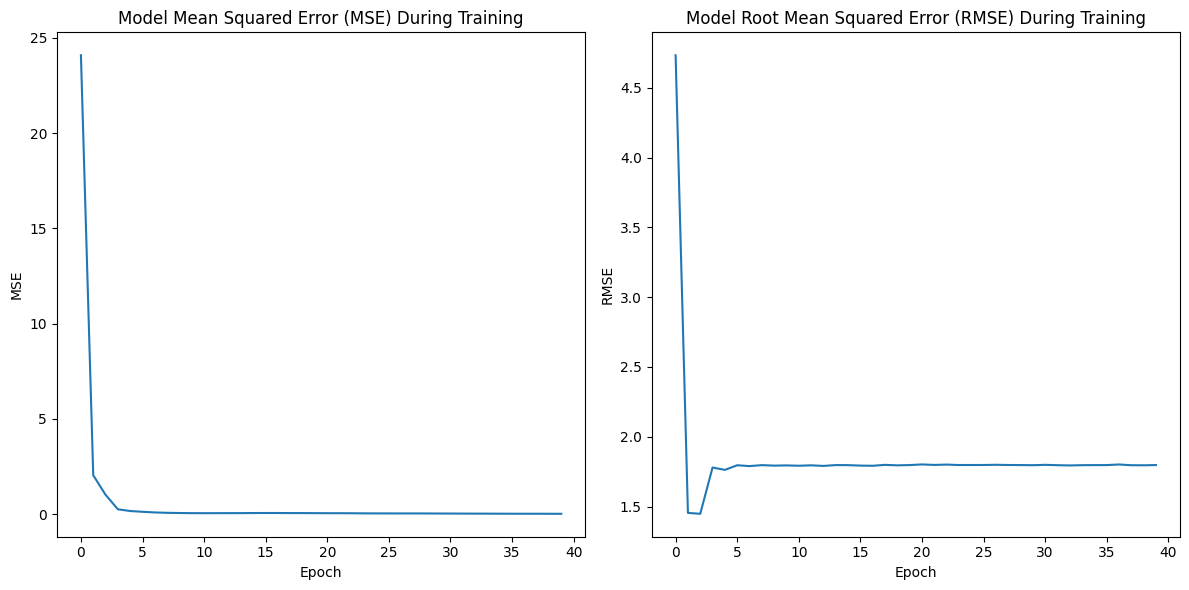

In [43]:
import matplotlib.pyplot as plt

# Mengambil data MSE dan RMSE dari history
mse = history.history['mean_squared_error']
rmse = history.history['rmse']

# Membuat plot MSE selama training
plt.figure(figsize=(12, 6))

# Plot MSE
plt.subplot(1, 2, 1)
plt.plot(mse)
plt.title('Model Mean Squared Error (MSE) During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE')

# Plot RMSE
plt.subplot(1, 2, 2)
plt.plot(rmse)
plt.title('Model Root Mean Squared Error (RMSE) During Training')
plt.xlabel('Epoch')
plt.ylabel('RMSE')

plt.tight_layout()
plt.show()